# Features and Correctness

We want to be able to describe our populations of sequences and compare them. To do this we extract various distributions, but we call them features. These features are designed such that they can be used to describe and measure correctness as a distance.

We define features as belonging to one of the following "domains":

- **Structural** features are designed to check for "structural zeros", ie outputs that should not be possible.
  - eg, if each sequence starts with a "home" activity
  - eg, if each sequence has a total duration of 24 hours
- **Participation** features check for the occurance of activity types in a sequence, they can be presented as **rates** or **probabilities**.
  - eg, if each sequence participates in the "work" activity or not
- **Transition** features describe the ordering of activities within sequences. 
  - eg, how many times a sequence transitions from "home" to "work"
- **times**/**scheduling** features describe when activities take place.
  - eg, the start time of all "shop" activities

We also use **frequency** features to describe the aggregate probability of an activity taking place in a given time bin. For example, "X% of agents are at work between 10am and 11am".

We also use **uniqueness** as a measure of diversity within a population of sequences.



In [1]:
import random

import pandas as pd

from acteval import ops, Population
from acteval.density.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from acteval.density.describe.transitions import sequence_prob_plot
from acteval.distance import emd, mape
from acteval.density.features import participation, times

In [2]:
# create some data
raw = pd.read_csv("data/synthetic_schedules.csv")


def down_sample(df, p):
    n_samples = int(len(df.pid.unique()) * p)
    sample_ids = random.sample(list(df.pid.unique()), n_samples)
    sampled = df[df.pid.isin(sample_ids)]
    return sampled


observed = down_sample(raw, 0.2)

a = down_sample(observed, 0.2)
b = down_sample(raw, 0.2)

synthetic = {"a": a, "b": b}



For example we can extract the start times for each activity and report the averages:

In [3]:
observed_population = Population(observed)
starts = times.start_times_by_act(observed_population)
ops.average(starts)

education    0.711806
home         0.350119
leisure      0.420387
shop         0.371071
work         0.425226
dtype: float64

Note that the starts feature is a dictionary of tuples. Where the first value describes the 'support' of the feature and the second the frequncy of each observation.

We can take a better look at the distributions by plotting them:

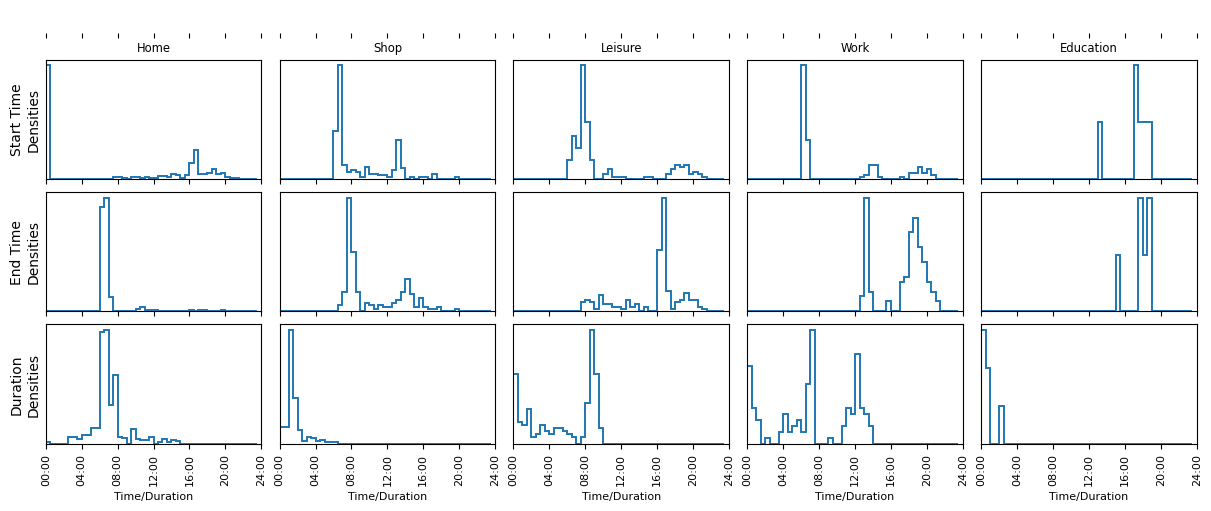

In [4]:
fig = times_distributions_plot(observed, None)

# Feature Structure

Features are commonly segmented into a dictionary of keys and values, where the key describes the segment. Features are commonly segmented by activity or transition type:

```
participation_probability = {
    "home": [1,1,1],
    "work": [1,0,0],
    "shop": [0,1,0]
}
```

In the above example, each feature segment records if each of the 3 segements contained a "home", "work" or "shop" activity.

In practice we compress this representation into frequency counts, represented by a tuple of the (i) possible values and (ii) their frequncies, in this simple case we get:

```
participation_probability = {
    "home": ([0, 1], [0, 3]),
    "work": ([0, 1], [2, 1]),
    "shop": ([0, 1], [2, 1]),
}
```

# Feature Descriptions

Features can be described or plotted using functions in the describe module:

In [5]:
participation_rates = participation.participation_rates_by_act(
    observed_population
)
print(ops.average(participation_rates))

education    0.030
home         2.065
leisure      0.805
shop         0.855
work         0.575
dtype: float64


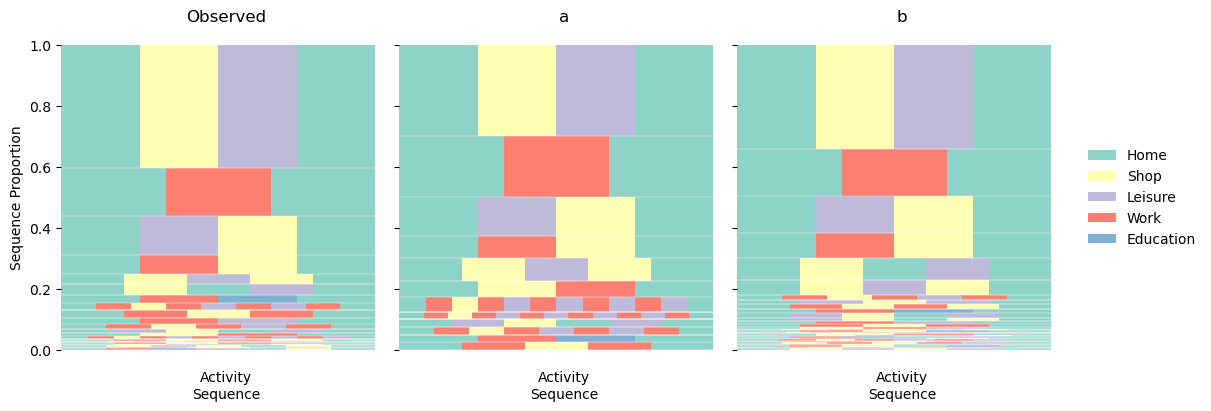

In [6]:
fig = sequence_prob_plot(observed, synthetic, figsize=(12, 4))

# Feature Segmentation

We can use more interesting types of segmentation to extact more descriptive features. For example we can enumerate activity type by it's location in the sequence:

In [7]:
participation_rates = participation.participation_rates_by_seq_act(
    observed_population
)
print(ops.average(participation_rates).head(10))

0home         1.000
10leisure     0.015
11home        0.010
11work        0.005
12home        0.005
1leisure      0.145
1shop         0.495
1work         0.360
2education    0.030
2home         0.190
dtype: float64


Or by the enumeration of that type of activity in each sequence:

In [8]:
participation_rates = participation.participation_rates_by_act_enum(
    observed_population
)
print(ops.average(participation_rates).head(10))

education0    0.030
home0         1.000
home1         1.000
home2         0.065
leisure0      0.720
leisure1      0.055
leisure2      0.015
leisure3      0.015
shop0         0.800
shop1         0.050
dtype: float64


In these examples we use additional segmentation to get more information about the sequence. For example we can differentiate between the participation in (i) education as the third activity (2education) versus the fourth activity (3education), or (ii) the first education activity (education0) versus the second education activity (education1).

In all cases we use weighted averaging to combine segmented features into single metrics. Where weighting is ussually the number of each feature in the observed population of sequences.

# Dimensions

Start times are a one dimensional feature, but we can also consider multi-dimensional features:

In [9]:
start_durations = times.start_and_duration_by_act_bins(
    observed_population, bin_size=10
)
# average 2d averages each dimension and then sums so that we can return an float
ops.average2d(start_durations)

education    0.738426
home         0.635694
leisure      0.644755
shop         0.430637
work         0.723128
dtype: float64

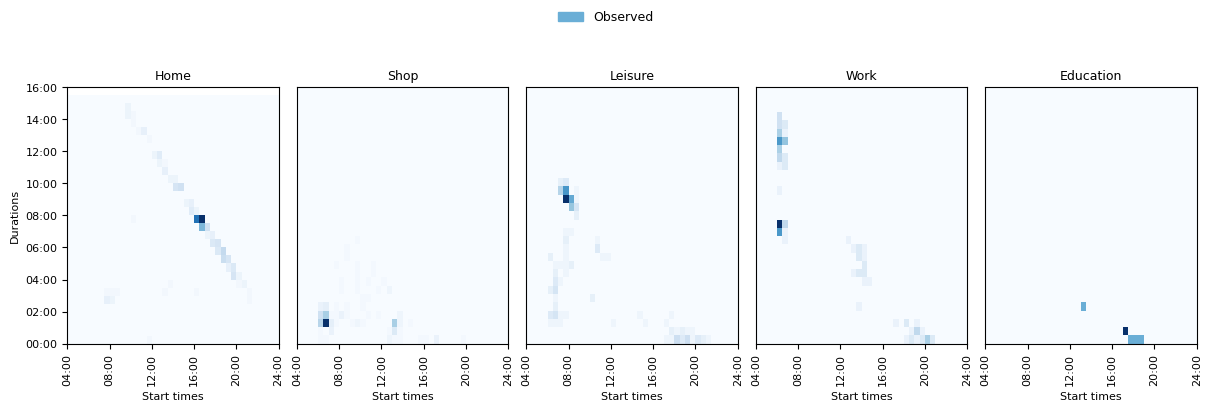

In [10]:
fig = joint_time_distributions_plot(observed, None, figsize=(12, 4))

# Distances

When comparing features we can generally see complex distributions:

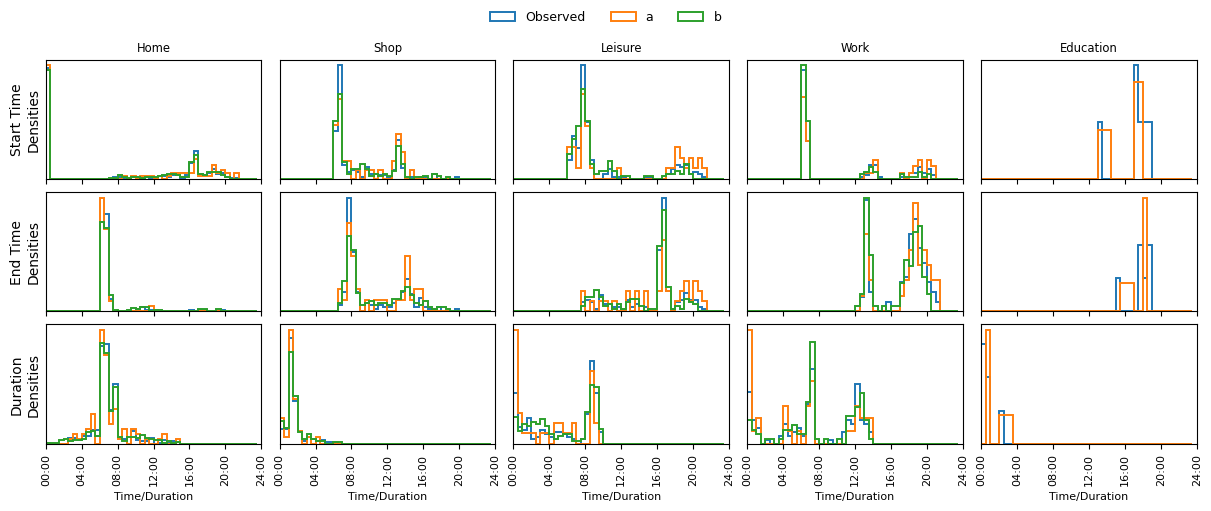

In [11]:
fig = times_distributions_plot(observed, synthetic)

To make a quantitave comparison between populations of sequences we primarilly use Wassersetin "earth movers" distance. This measure the amount of "work" required to make one distribuion match another.

In [12]:
x = times.start_times_by_act(observed_population)
a, b = Population(a), Population(b)

ya = times.start_times_by_act(a)
yb = times.start_times_by_act(b)
print("synthetic population A: ", emd(x["home"], ya["home"]))
print("synthetic population B: ", emd(x["home"], yb["home"]))

synthetic population A:  0.015457632100758267
synthetic population B:  0.013327506644762347


In this case we might proclaim population B to be better. In practice we will use a lot more features and there will generally be trade-offs between them.

For probability features (in particular participation) we also sometime use absolute percentage error. This is particularly useful for highlighting the participation in uncommon activities which are often problematic for generative models.

In [13]:
x = participation.participation_prob_by_act(observed_population)
ya = participation.participation_prob_by_act(a)
yb = participation.participation_prob_by_act(b)
print("synthetic population A: ", mape(x["leisure"], ya["shop"]))
print("synthetic population B: ", mape(x["leisure"], yb["shop"]))

synthetic population A:  0.07096774193548393
synthetic population B:  0.11656441717791409


By this metric, population A appears better.